In [1]:
'''
Read leakage data from files created by the script leakage_data.ipynb which contain the mean and stdev
of Dataword-Pedestal values from data runs conducted with resets disabled. For each channel calculate the slope 
of mean versus # of trigger cycles. Channels whose means are linearly increasing with trigger cycles 
indicate leakage.

'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime
from scipy import stats

##########################################################
# Initialize parameters  
##########################################################

# tiles potentially tested in this filename
tiles = [1,2,3,4,5,6,7,8,9,10]
#tiles = [2]

set = 2

# the # of periodic trigger cycles specified in the filename (e.g. the "leak10) should be among this list
filename_cycles = ['150k', '300k', '600k', '800k']
cycles = [150000, 300000, 600000, 800000]

ncycles = len(cycles)

# serial numbers for set 1 of tiles 1-10
chip_serial_number_list = ['', '4k02056', '4k03591', '4k01892', '4k02219', '4k02371', '4k04834', '4k00101', '4K00277', '4K03329', '4K04087' ]

# serial numbers for sets 2 and 3 
if set ==2:
    chip_serial_number_list = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ]
elif set==3:
    chip_serial_number_list = ['', '4k00952', '4k03591', '4k03936', '4k00607', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]
elif set==4:
    chip_serial_number_list = ['', '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ]    

temp = 'cold'

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False
n_graphed  = 0
n_to_graph = 50

leakage_means  = [[[[0 for cycle in range(ncycles)] for chan in range(64)] for chip in range(171)] for tile in range(11)] 
leakage_stdevs = [[[[0 for cycle in range(ncycles)] for chan in range(64)] for chip in range(171)] for tile in range(11)]

slopes         = [[[0 for chan in range(64)] for chip in range(171)] for tile in range(11)]
r_sqrs         = [[[0 for chan in range(64)] for chip in range(171)] for tile in range(11)] 
p_std_graph    = [[[0 for chan in range(64)] for chip in range(171)] for tile in range(11)]
stdevs_graph   = [[[0 for chan in range(64)] for chip in range(171)] for tile in range(11)]
ped_stdevs     = [[[0 for chan in range(64)] for chip in range(171)] for tile in range(11)] 

In [2]:
# read leakage data (mean and stdev by channel) from files previously created by the script leakage_data.ipynb
def read_leakage_from_file(tile, cycle_index):

    global temp, leakage_means, leakage_stdevs, filename_cycles, verbose_tile, verbose_chip, verbose_chan
    global chip_serial_number, stdevs_graph, ped_stdevs
    
    # read data in a file of leakage (mean and stdev) by channel
    filename = f'../data/leakage_{temp}_tile{chip_serial_number}_{filename_cycles[cycle_index]}cycles.hdf5'

    f = h5py.File(filename, 'r')
    means            = f['leakage_means'][:]
    stdevs           = f['leakage_stdevs'][:]  
    ped_stdevs[tile] = f['ped_stdevs'][:] 
                
    # read data in for each cycle 
    for chip in range(11,171):

        for chan in range(64):
                    
            leakage_means[tile][chip][chan][cycle_index]   = means[chip][chan]
            leakage_stdevs[tile][chip][chan][cycle_index]  = stdevs[chip][chan] 

            #if tile ==verbose_tile and chip == verbose_chip and chan == verbose_chan:
            #    print(f"Verbose channel {tile}-{chip}-{chan} cycle {filename_cycles[cycle_index]} means {leakage_means[tile][chip][chan][cycle_index]:.1f}")

    
    f.close()
    
    return


In [3]:
# for each channel in a given tile, calculate the slope of mean versus cycles 
def calculate_slope(tile, means):

    global slopes, r_sqrs, leakage_stdevs, cycles, chip_serial_number, verbose_tile, verbose_chip, verbose_chan, stdevs_graph
    global n_graphed, n_to_graph, ped_stdevs, p_std_graph, results

    # serial #s uniquely identifying the chip located in the top left corner of each tile, when looking at it with 
    # the power and data connectors at the top. The following key is needed when storing results in the dictionary
    tile_result_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                     '4k00952', '4k03591', '4k03936', '4k00607', \
                     '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']
    
    if chip_serial_number in tile_result_keys:
        tile_index = tile_result_keys.index(chip_serial_number)
    else:
        print(f"\nProblem: tile {chip_serial_number} was not found in the results dictionary tile list. Its results will not be stored")    

    first_try = True 

    for chip in range(11, 171):
        for chan in range(64):

            flat_means = np.array(means[tile][chip][chan]).flatten()
            flat_cycles = np.array(cycles).flatten()
            
            if sum(flat_means) > 0:
                try:
                    slope, intercept, r_value, p_value, std_err = stats.linregress(flat_cycles, flat_means)   
                except:
                    print(f"Problem getting slope for Chip-Chan {chip}-{chan}:\n\tcycles {flat_cycles} \n\tMeans {flat_means}")

                slopes[tile][chip][chan] = slope * (cycles[-1] - cycles[0])
                r_sqrs[tile][chip][chan] = r_value**2
                stdevs_graph[tile][chip][chan] = leakage_stdevs[tile][chip][chan][1]
                p_std_graph[tile][chip][chan]  = ped_stdevs[tile][chip][chan]

                # load the results dictionary
                results['leakage_scaling'][tile_index][chip][chan]   = slopes[tile][chip][chan]
                
                # Graph means versus cycles for channels with high leakage stdev but low pedestal stdev 
                #if stdevs_graph[tile][chip][chan] > 4 and ped_stdevs[tile][chip][chan] < 1 and slopes[tile][chip][chan] > 2 and n_graphed < n_to_graph:    
                if stdevs_graph[tile][chip][chan] > 4 and ped_stdevs[tile][chip][chan] < 1 and n_graphed < n_to_graph:    

                    n_graphed +=1

                    y_min = intercept
                    y_max = intercept + slope * ( max(flat_cycles) - min(flat_cycles) )

                    fig, ax = plt.subplots(figsize=(6, 3))
                    ax.scatter(flat_cycles, flat_means)
                    ax.plot([min(flat_cycles), max(flat_cycles) ], [ y_min, y_max ], linestyle = "--", color = 'r')
                    ax.set_title(f'Tile-Chip-Chan {tile}-{chip}-{chan} Mean vs Trigger Cycles\nSlope = {slopes[tile][chip][chan]:.0f}, Stdev = {stdevs_graph[tile][chip][chan]:.0f}\n{temp} Leakage test, v3a Tile #{tile} ({chip_serial_number})')
                    #plt.text(250, 400, f"Slope = {slope:.1f}\nR-Squared = {r_value**2:.3f}", color = 'r')
                    ax.set_ylabel(f'Mean(Dataword) - Mean(Pedestal)')
                    ax.set_xlabel(f'Periodic Trigger Cycles')    
                    plt.show    

    return

In [4]:
def graph_slopes(tile, slopes, r_sqrs, stdevs, ped_stdevs):

    global chip_serial_number, leakage_means, cycles

    flat_slopes     = np.array(slopes[tile]).flatten()
    flat_r_sqrs     = np.array(r_sqrs[tile]).flatten()
    flat_stdevs     = np.array(stdevs[tile]).flatten()
    flat_ped_stdevs = np.array(ped_stdevs[tile]).flatten()   

    # disregard channels were r_sqr is at it's initialization value (i.e. disabled channels or those from chips 0-10)
    rsqr_mask       = flat_r_sqrs[:] != 0
    flat_slopes     = flat_slopes[rsqr_mask]
    flat_r_sqrs     = flat_r_sqrs[rsqr_mask]
    flat_stdevs     = flat_stdevs[rsqr_mask]
    flat_ped_stdevs = flat_ped_stdevs[rsqr_mask]
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(flat_slopes, flat_r_sqrs, alpha = 0.08)
    ax.set_title(f'Slope Fitted Through Mean(cycles)\n{temp} Leakage test, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Slope')
    ax.set_ylabel(f'R-Squared of Linear Fit')    
    plt.show

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(flat_slopes, flat_stdevs, alpha = 0.08)
    ax.set_title(f'Leakage Slope versus Stdev\n{temp} Leakage test, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Slope')
    ax.set_ylabel(f'Leakage Stdev')    
    plt.show

    count_all, count_positive, count_1 = 0,0,0
    x, y = [], []
    
    for i in range(len(flat_ped_stdevs)):
        if flat_ped_stdevs[i] < 1.2 and flat_ped_stdevs[i] > 0 and flat_stdevs[i] > 4:
            x.append(flat_slopes[i])
            y.append(flat_stdevs[i])
            count_all += 1
            if flat_slopes[i] > 0:
                count_positive +=1
                if flat_slopes[i] > 1:
                    count_1 +=1
                    

    percent_positive = 100*count_positive / count_all
    percent_1        = 100*count_1        / count_all

    print(f"{percent_positive:.0f}% of slopes are positive, {percent_1:.0f}% slopes > 1")
    
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.scatter(x, y, alpha = 0.4, color = 'g')
    ax.set_title(f'Channels that Become Noisy in Leakage Tests: Slope versus Leakage Stdev ({percent_positive:.0f}% of slopes > 0)\n{temp} Leakage test, v3a Tile #{tile} ({chip_serial_number})')
    ax.set_xlabel(f'Fitted Slope * Delta Trigger Cycles')
    ax.axvline(x=0, color = 'r', linestyle = '--')
    ax.set_ylabel(f'Leakage Stdev')    
    plt.show    
    
    return

In [5]:
# import the dictionary which logs test results by channel for all v3a tests
def import_results_dictionary():

    global results, results_filename, temp

    # establish filename that holds the results dictionary
    first_tile = 1
    last_tile = 24
    chip_version  = "v3a"
    date = "2026-06-29_08:29"
    results_filename = f'/data/v3/10x16/results_{chip_version}_tiles_{first_tile}-{last_tile}_{temp}_created_{date}.hdf5'

    with h5py.File(results_filename, "r") as f:
        results = {}
        for key, item in f.items():
            data = item[()]
            results[key] = data    

    print(f'\tResults dictionary read from file {results_filename}')
          
    return

In [6]:
def store_results():

    global results, results_filename
    
    with h5py.File(results_filename, 'w') as f:
        
        for key, chan_list in results.items():
            f.create_dataset(key, data=np.array(chan_list))
    
        f.close()  
        
    print(f"\n\nUpdated results dictionary in {results_filename}") 

    return

	Results dictionary read from file /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5


/tmp/ipykernel_3977077/2111942360.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 3))


24% of slopes are positive, 1% slopes > 1
69% of slopes are positive, 0% slopes > 1
17% of slopes are positive, 2% slopes > 1
79% of slopes are positive, 42% slopes > 1
60% of slopes are positive, 17% slopes > 1
70% of slopes are positive, 25% slopes > 1
29% of slopes are positive, 2% slopes > 1
68% of slopes are positive, 5% slopes > 1
62% of slopes are positive, 4% slopes > 1
56% of slopes are positive, 0% slopes > 1


Updated results dictionary in /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5


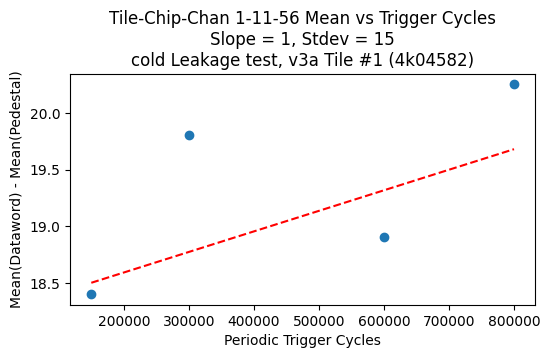

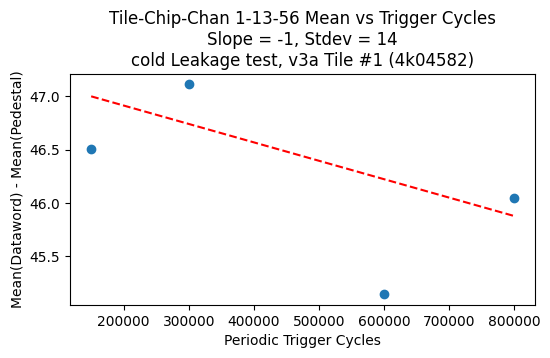

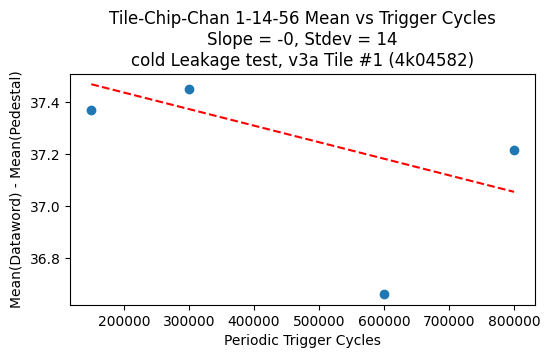

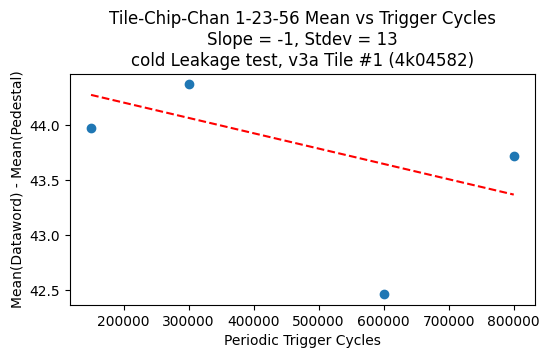

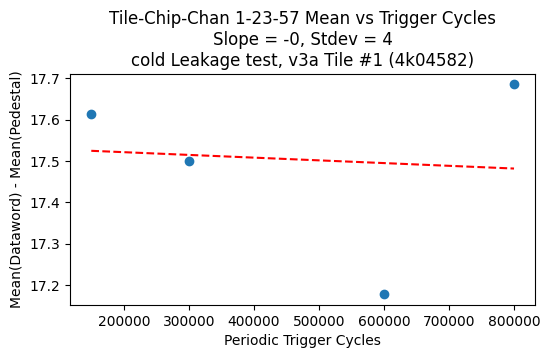

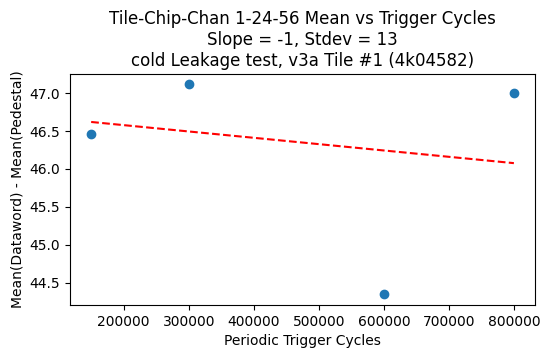

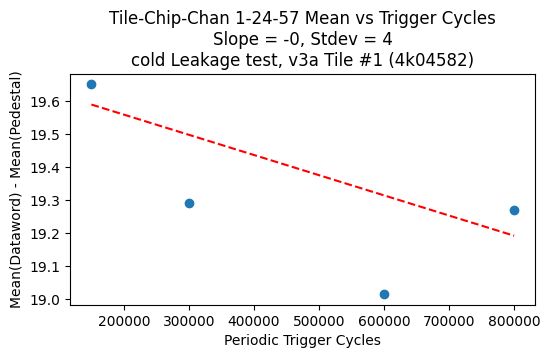

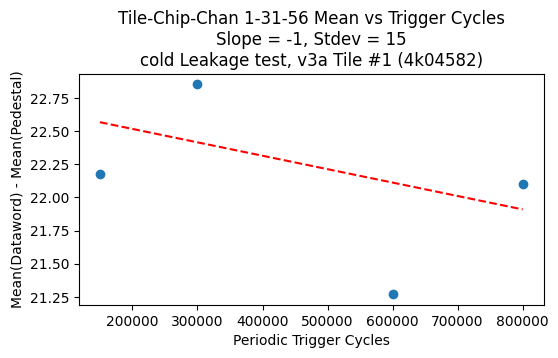

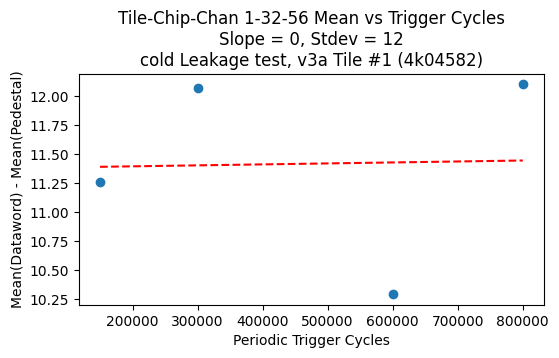

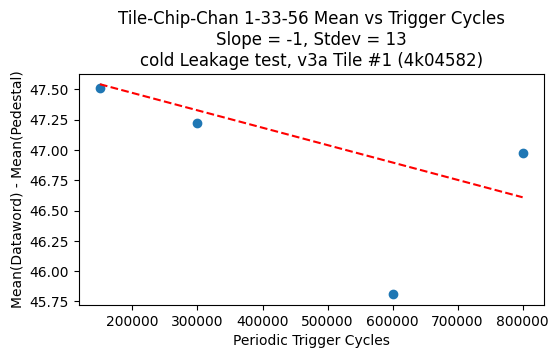

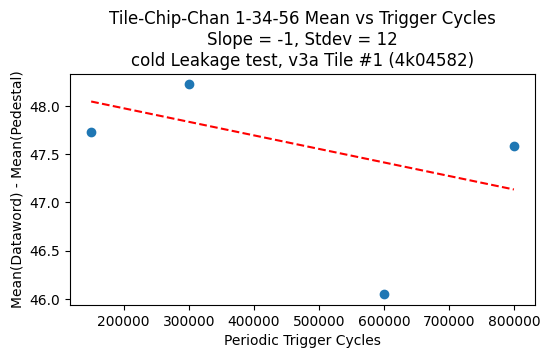

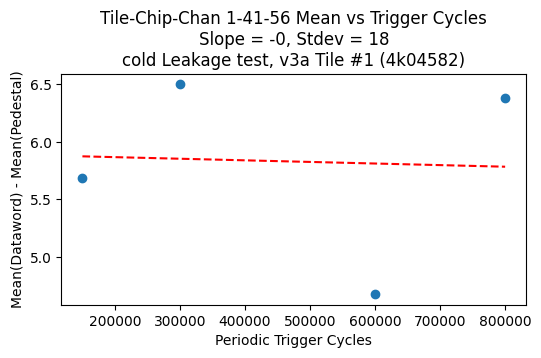

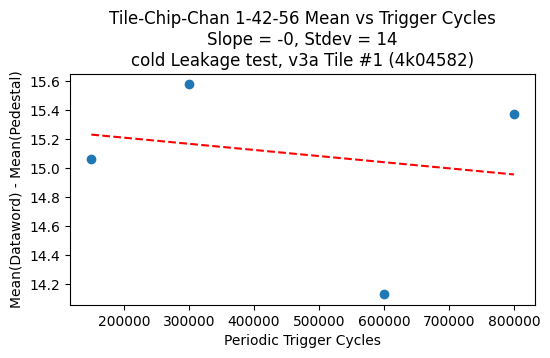

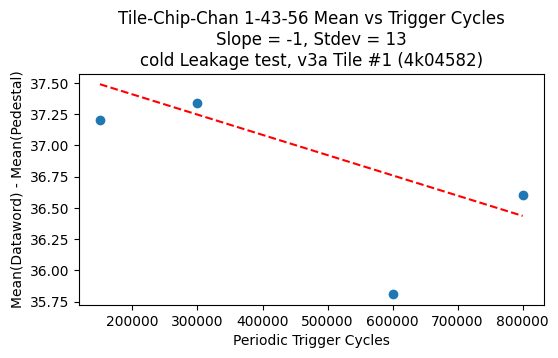

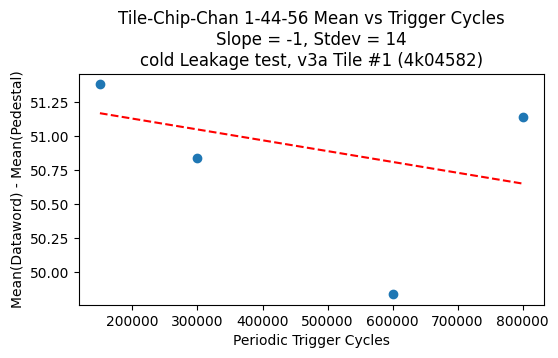

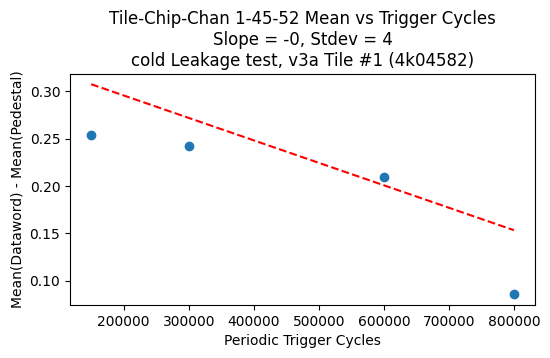

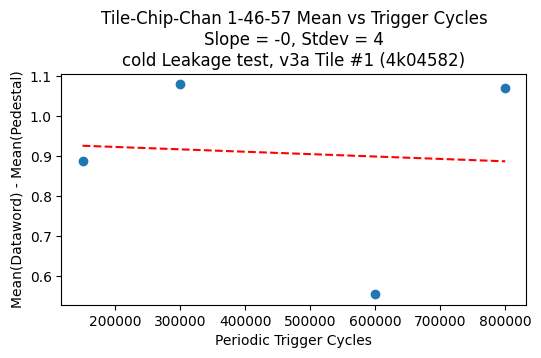

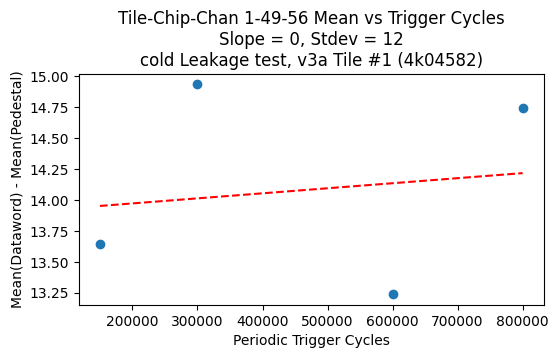

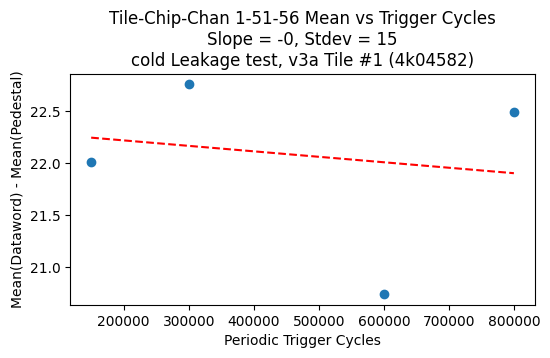

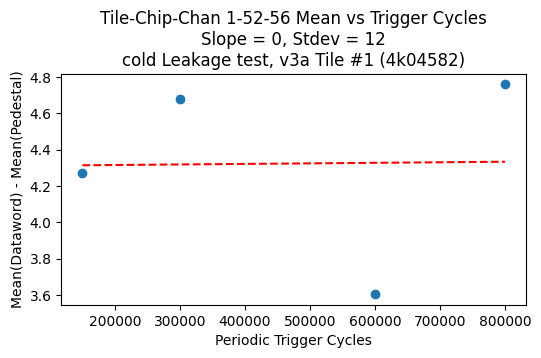

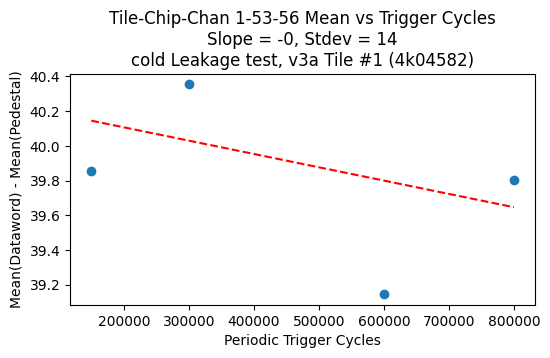

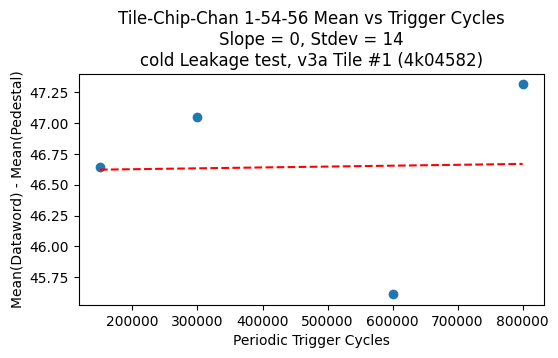

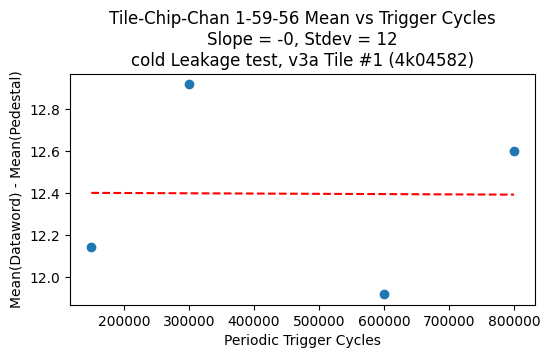

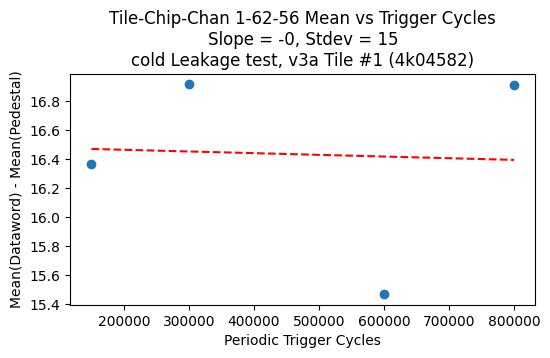

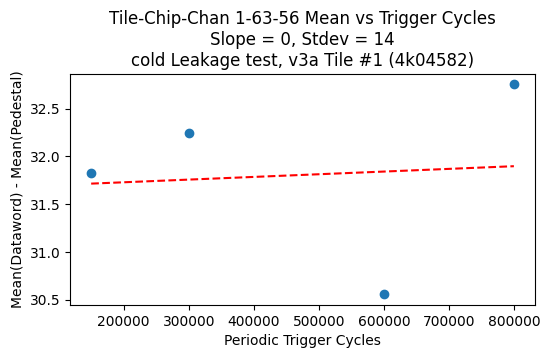

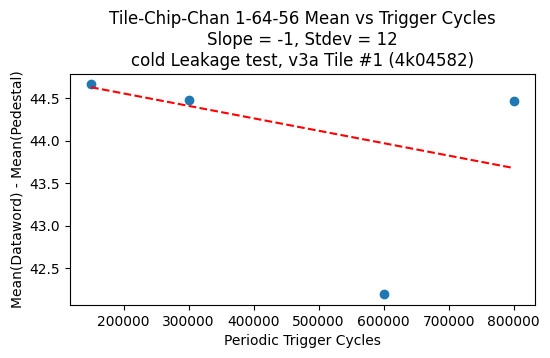

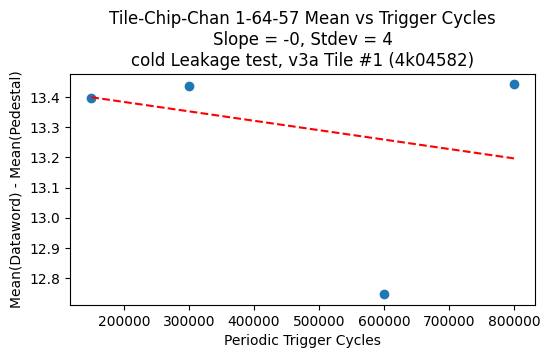

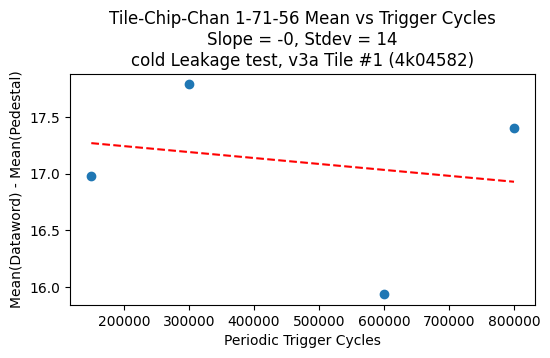

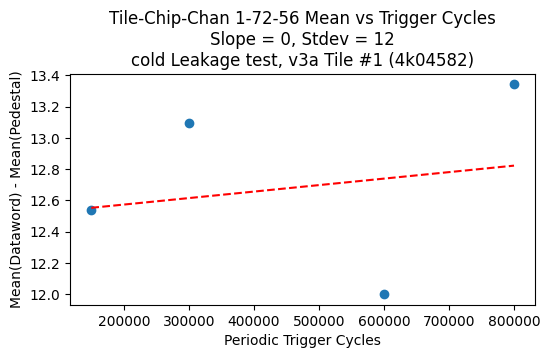

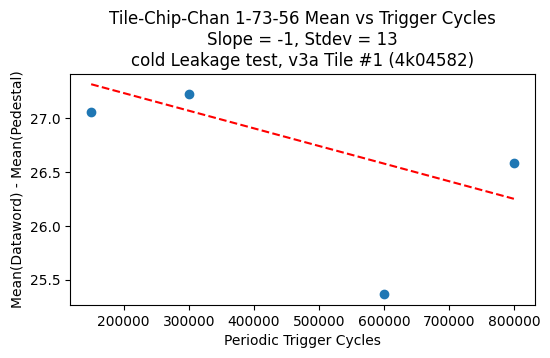

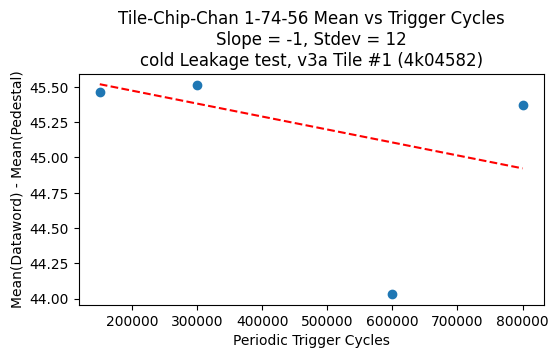

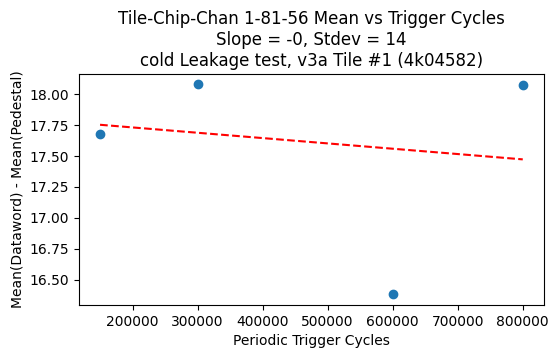

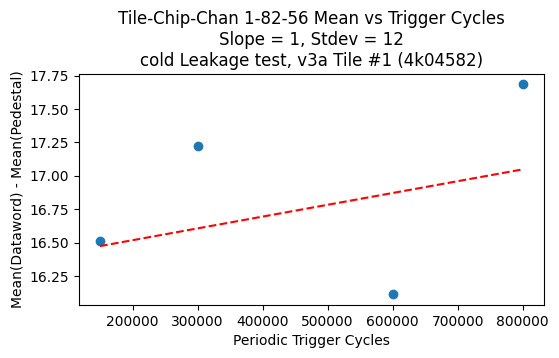

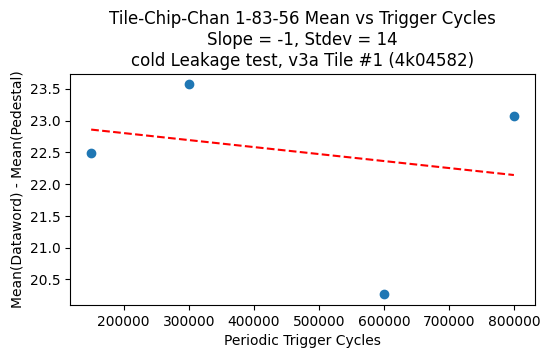

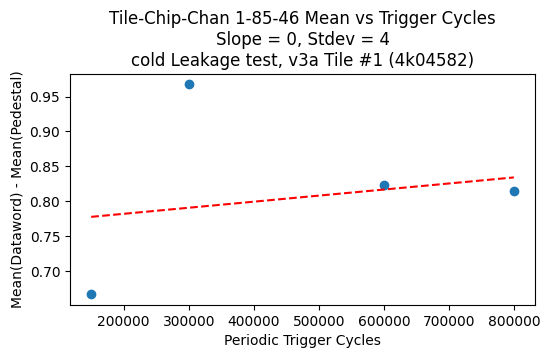

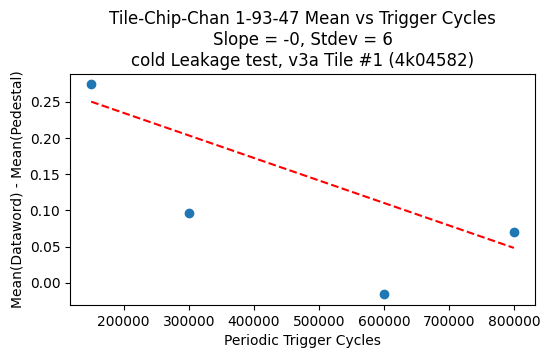

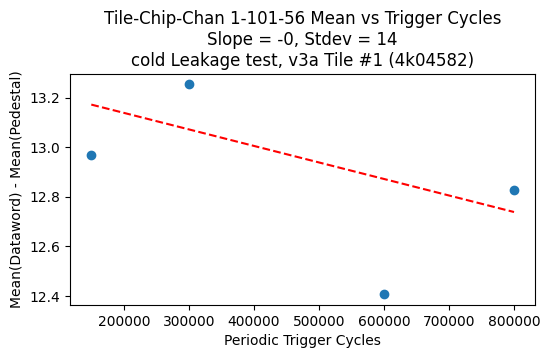

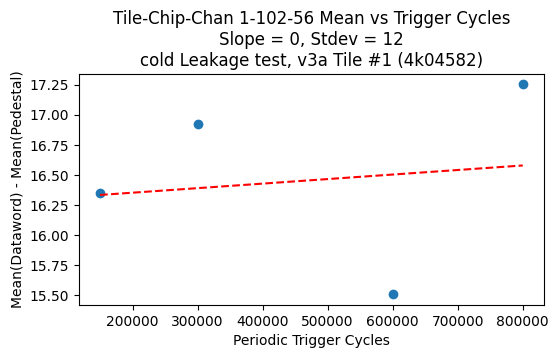

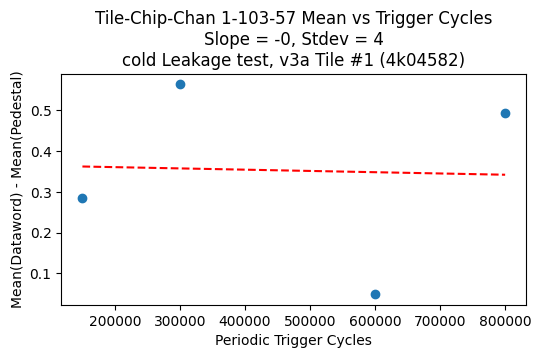

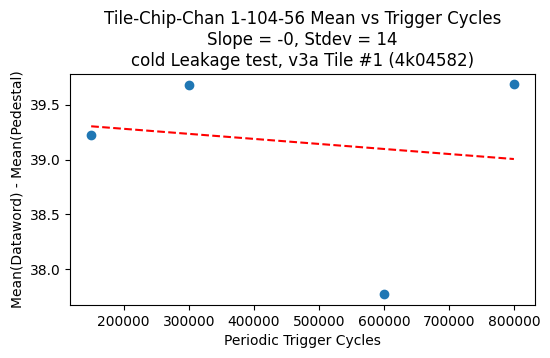

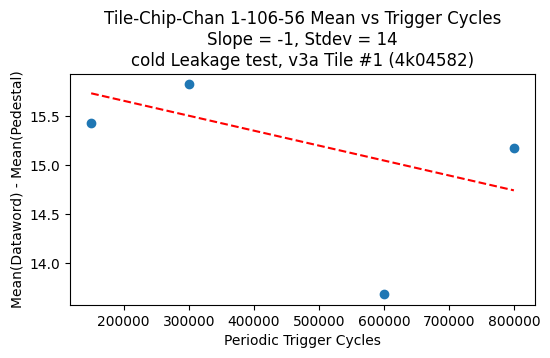

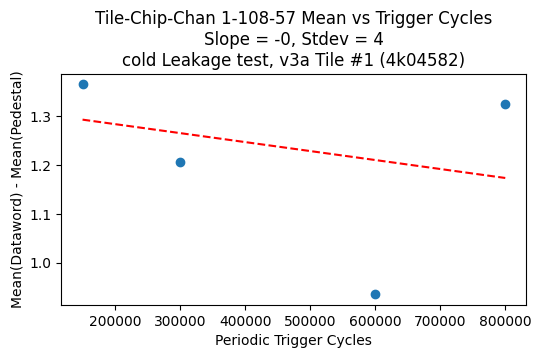

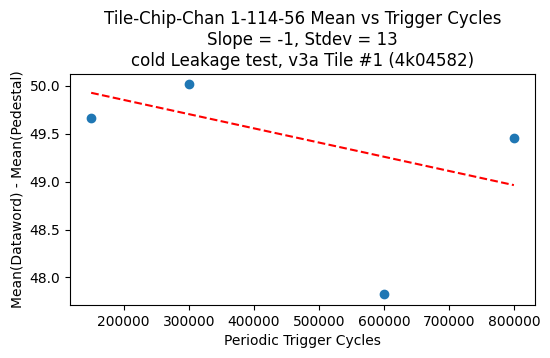

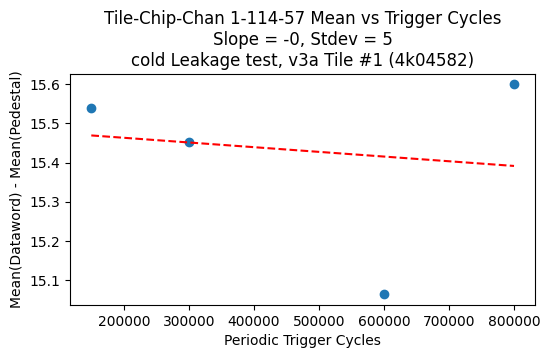

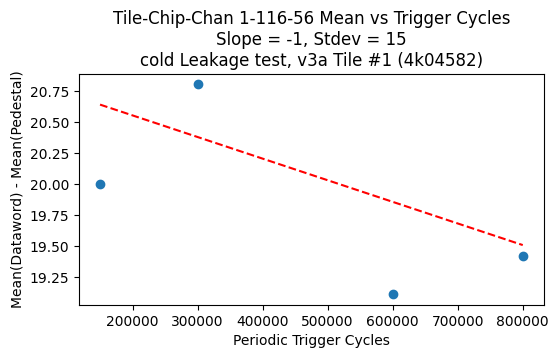

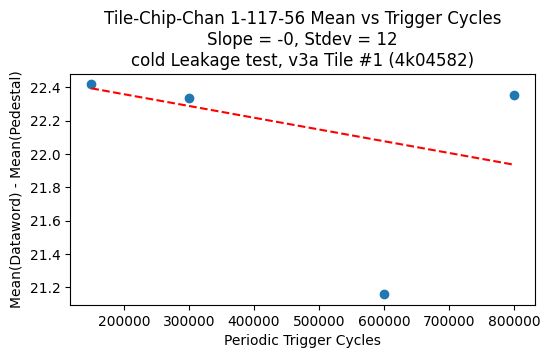

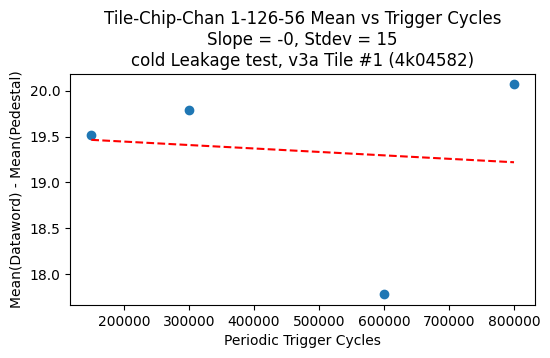

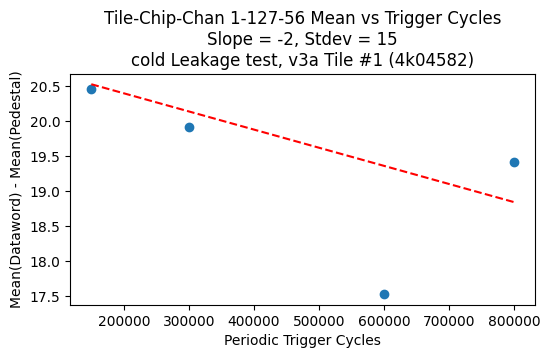

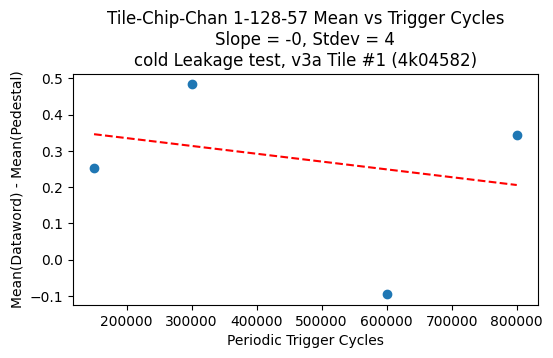

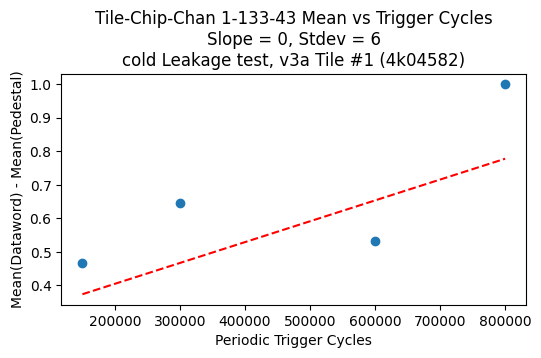

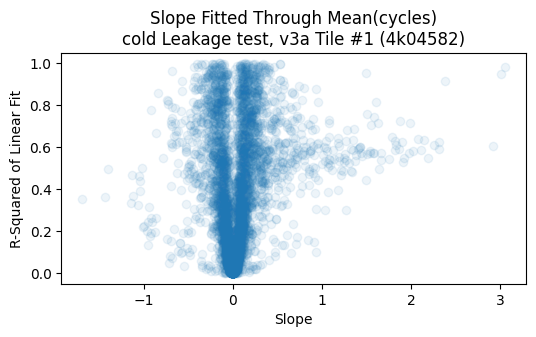

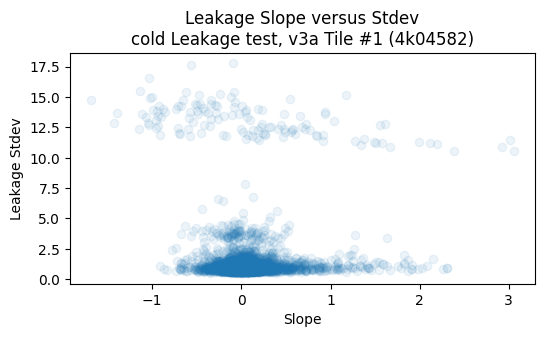

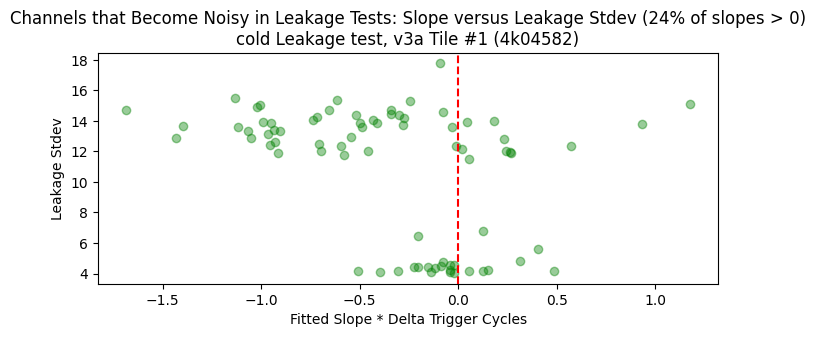

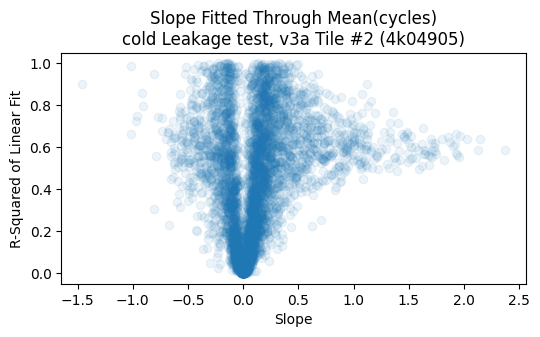

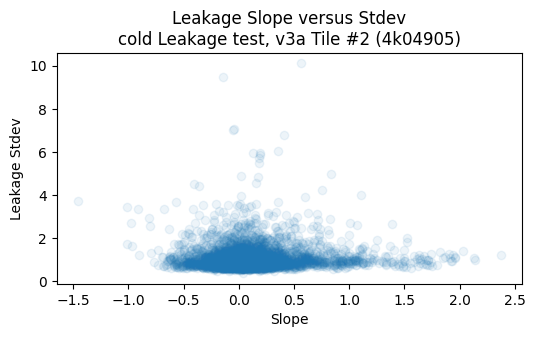

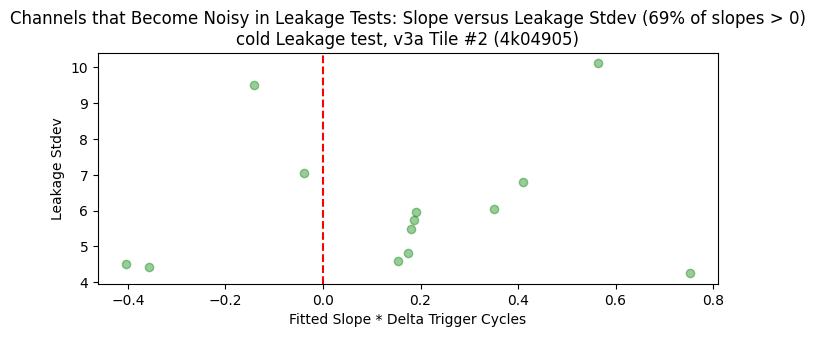

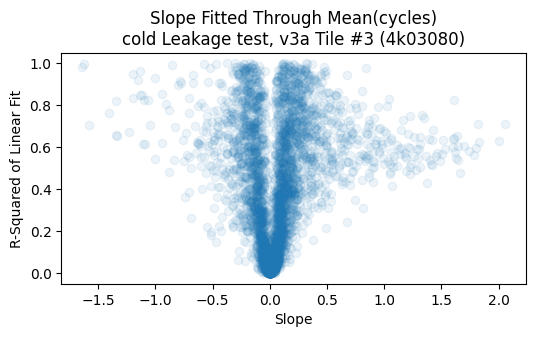

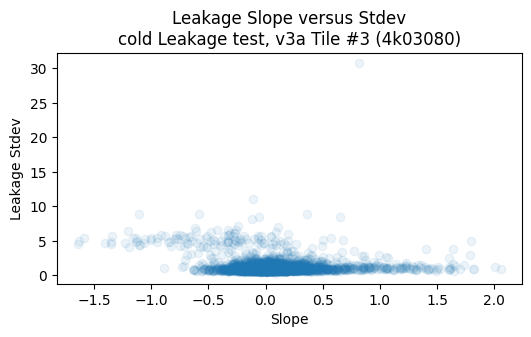

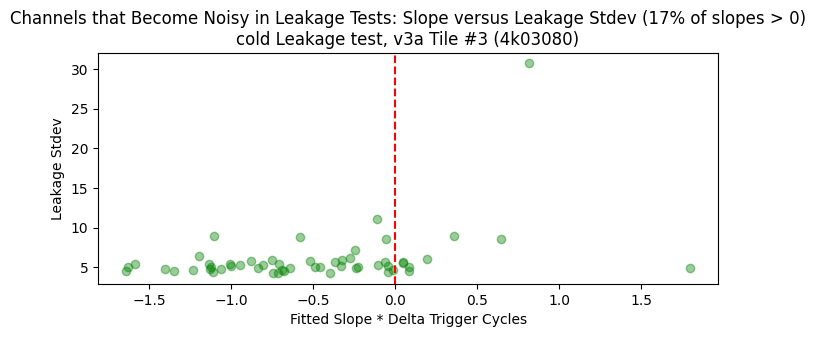

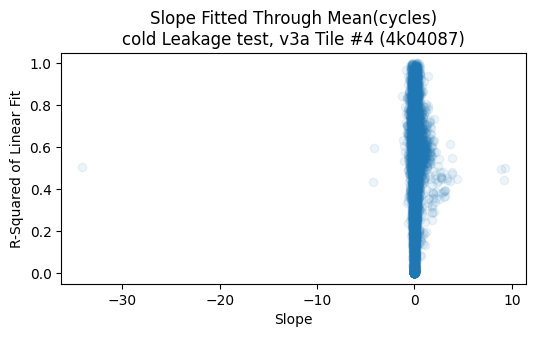

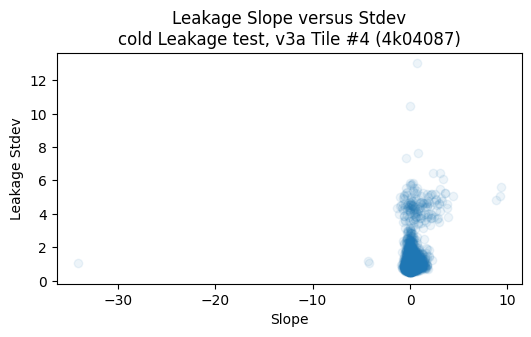

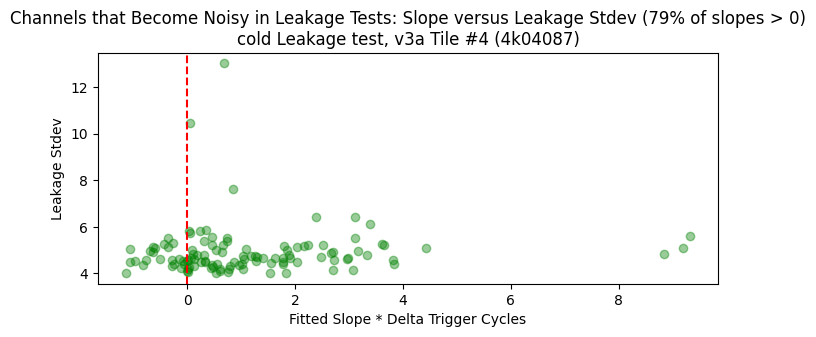

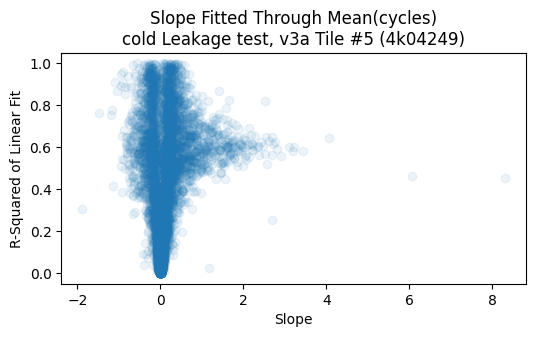

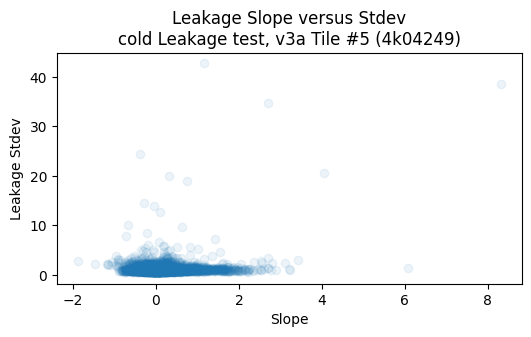

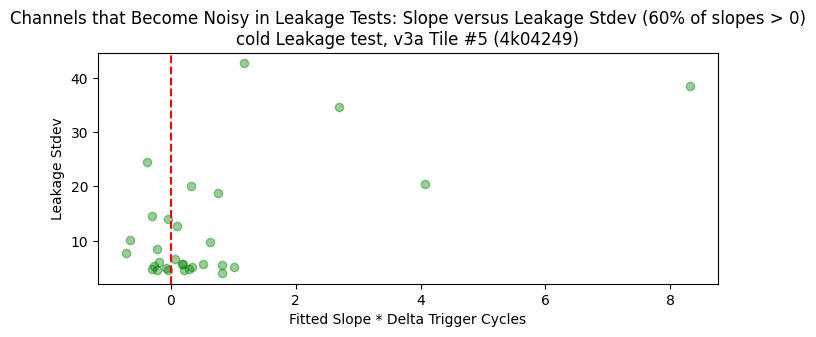

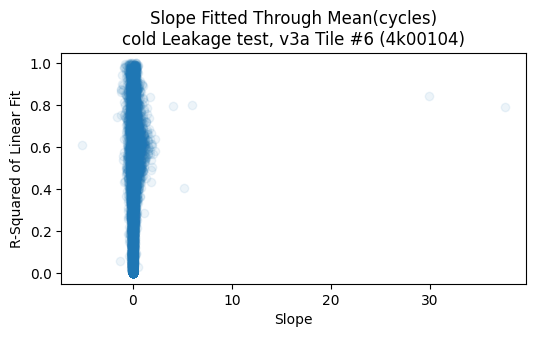

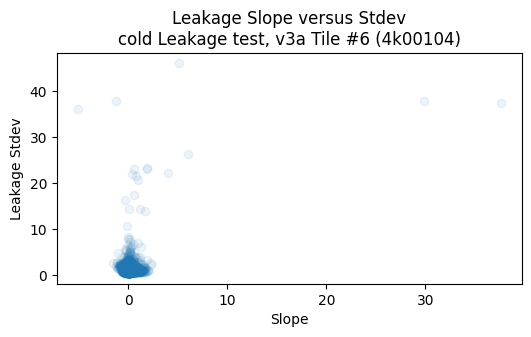

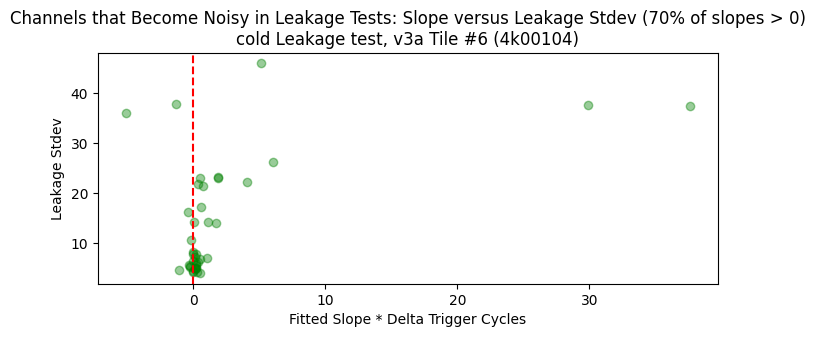

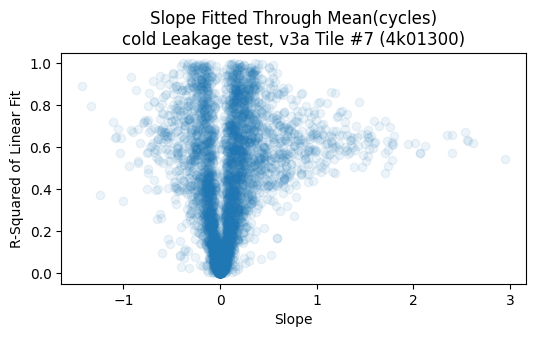

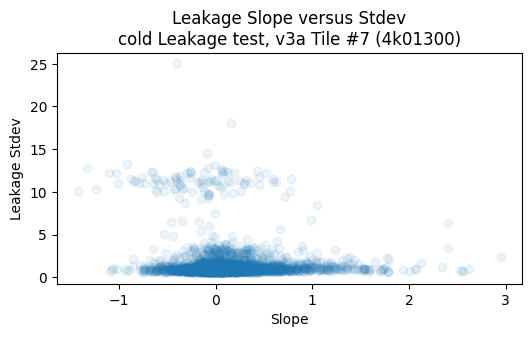

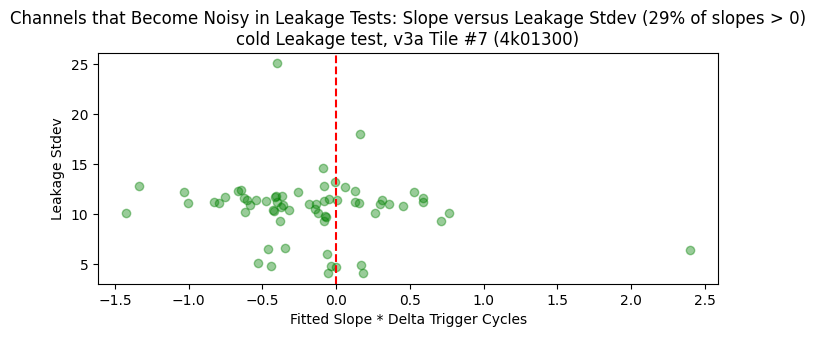

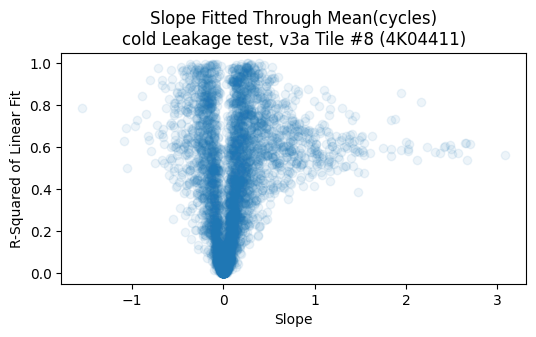

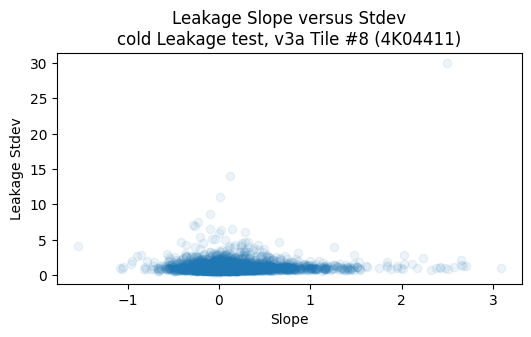

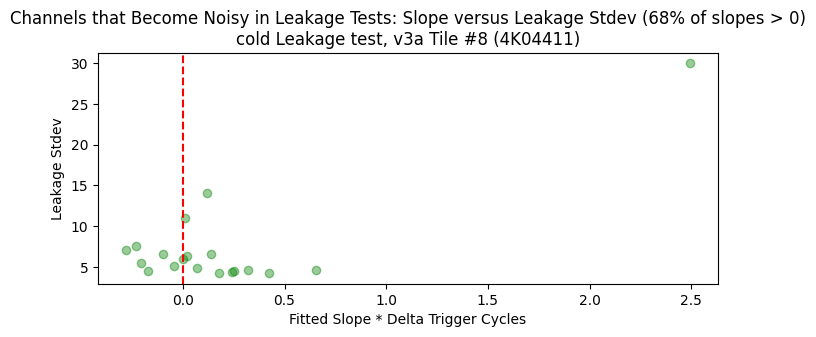

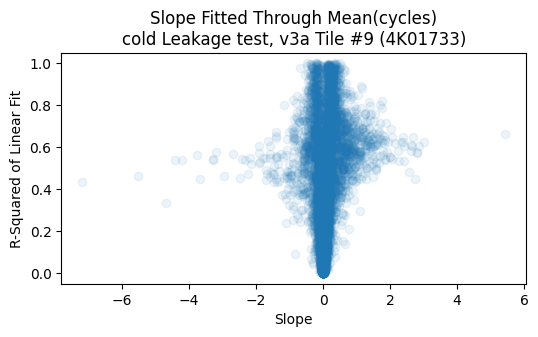

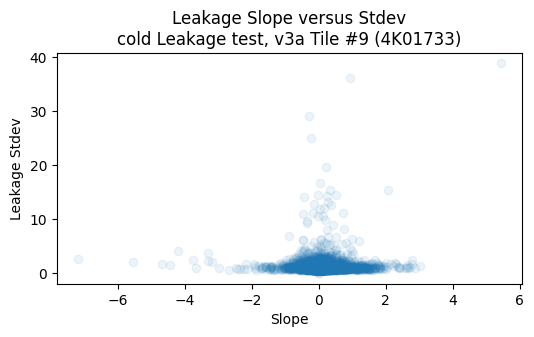

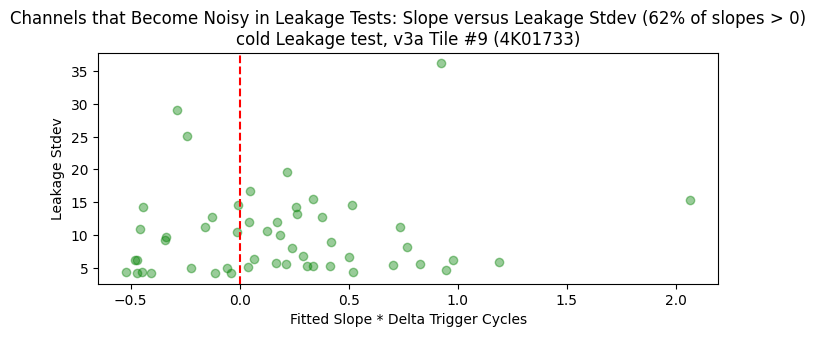

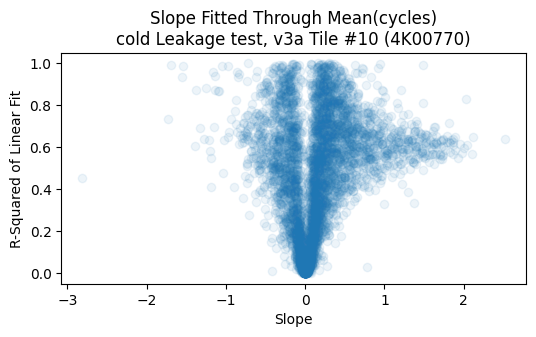

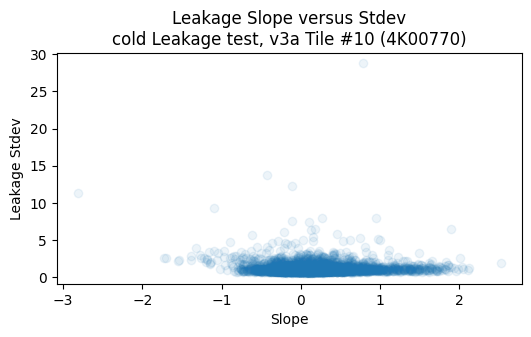

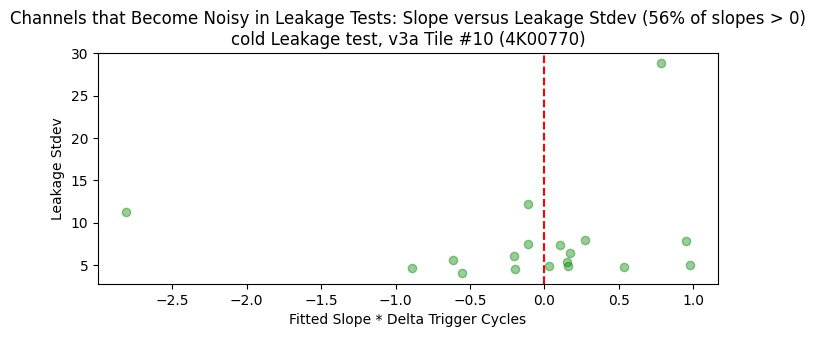

In [7]:
# main

# get the channel-specific results dictionary that holds results for all tiles from all tests 
import_results_dictionary()

for tile in tiles:
    
    chip_serial_number = chip_serial_number_list[tile]
    
    for cycle_index in range(len(filename_cycles)):
        
        read_leakage_from_file(tile, cycle_index)

    calculate_slope(tile, leakage_means)

    graph_slopes(tile, slopes, r_sqrs, stdevs_graph, p_std_graph)

store_results()       